In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

from tensorflow.keras.models import load_model

In [3]:
# Load Saved Model
model = load_model("../models/disease_model.keras")

print("Model Loaded Successfully")

Model Loaded Successfully


In [5]:
# Load Dataset
dataset_path = "../dataset/disease"

classes = [
    "Tomato_Early_blight",
    "Tomato_healthy",
    "Tomato_Late_blight",
    "Tomato_Leaf_Mold"
]

label_mapping = {
    "Tomato_Early_blight": 0,
    "Tomato_healthy": 1,
    "Tomato_Late_blight": 2,
    "Tomato_Leaf_Mold": 3
}

IMG_SIZE = 224

X = []
y = []

for cls in classes:

    folder_path = os.path.join(dataset_path, cls)

    for image_name in os.listdir(folder_path):

        image_path = os.path.join(folder_path, image_name)

        img = cv2.imread(image_path)

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        X.append(img)

        y.append(label_mapping[cls])

X = np.array(X)
y = np.array(y)

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [7]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Train/Test Split Completed")

Train/Test Split Completed


In [8]:
# Predict on Test Data
y_pred_prob = model.predict(X_test)

y_pred = np.argmax(
    y_pred_prob,
    axis=1
)

print("Prediction Completed")

35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 221ms/step
Prediction Completed


In [9]:
# Accuracy
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.9340054995417049


In [10]:
# Classification Report
report = classification_report(
    y_test,
    y_pred,
    target_names=classes
)

print(report)

                     precision    recall  f1-score   support

Tomato_Early_blight       0.92      0.79      0.85       200
     Tomato_healthy       0.99      1.00      0.99       318
 Tomato_Late_blight       0.90      0.95      0.92       382
   Tomato_Leaf_Mold       0.94      0.94      0.94       191

           accuracy                           0.93      1091
          macro avg       0.94      0.92      0.93      1091
       weighted avg       0.93      0.93      0.93      1091



In [11]:
# Save Classification Report
report_dict = classification_report(
    y_test,
    y_pred,
    target_names=classes,
    output_dict=True
)

report_df = pd.DataFrame(
    report_dict
).transpose()

report_df.to_csv(
    "../results/classification_report.csv"
)

print("Classification Report Saved")

Classification Report Saved


In [13]:
# Confusion Matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[158   2  36   4]
 [  0 317   0   1]
 [ 10   1 364   7]
 [  4   1   6 180]]


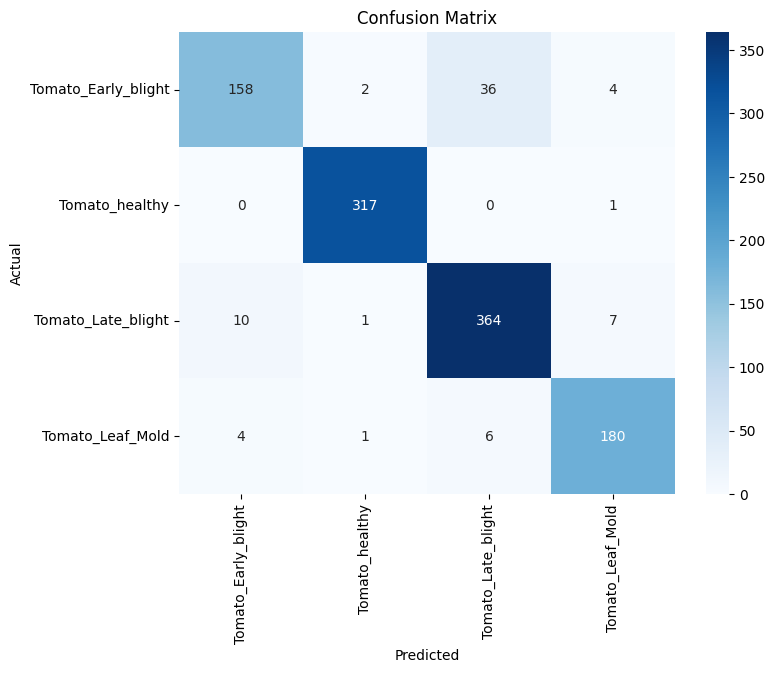

In [14]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

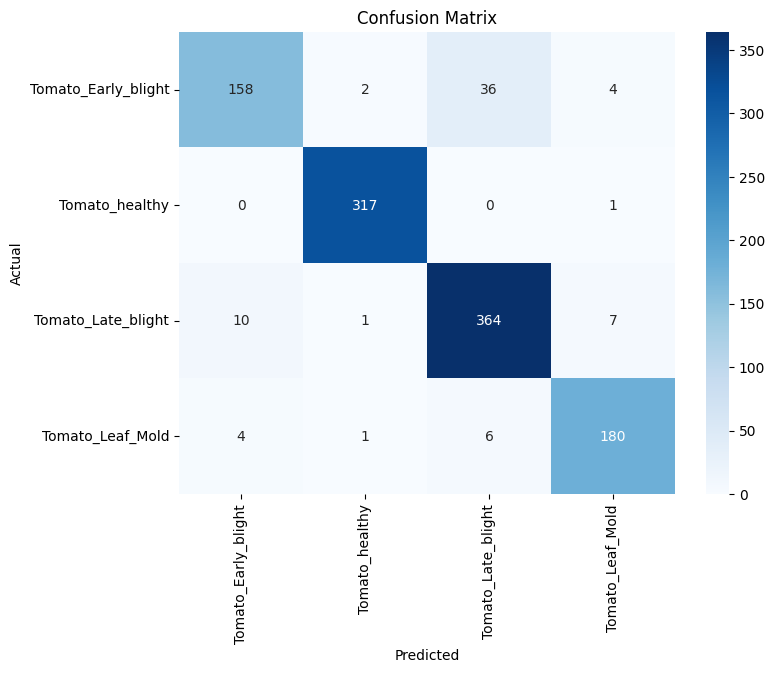

Confusion Matrix Saved


In [15]:
# Save Confusion Matrix
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.savefig(
    "../results/confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

print("Confusion Matrix Saved")

In [16]:
# Display Metrics Table
report_df

,precision,recall,f1-score,support
Tomato_Early_blight,0.918605,0.790000,0.849462,200.000000
Tomato_healthy,0.987539,0.996855,0.992175,318.000000
Tomato_Late_blight,0.896552,0.952880,0.923858,382.000000
Tomato_Leaf_Mold,0.937500,0.942408,0.939948,191.000000
accuracy,0.934005,0.934005,0.934005,0.934005
macro avg,0.935049,0.920536,0.926361,1091.000000
weighted avg,0.934284,0.934005,0.932950,1091.000000
